In [48]:
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
Customer=pd.read_csv("D:/Credit Card Case Study/Customer Acqusition.csv")


In [50]:
print(Customer.head())


   No Customer  Age       City   Product     Limit Company        Segment
0   1       A1   76  BANGALORE      Gold  500000.0      C1  Self Employed
1   2       A2   71   CALCUTTA    Silver  100000.0      C2   Salaried_MNC
2   3       A3   34     COCHIN  Platimum   10000.0      C3   Salaried_Pvt
3   4       A4   47     BOMBAY  Platimum   10001.0      C4           Govt
4   5       A5   56  BANGALORE  Platimum   10002.0      C5  Normal Salary


In case age is less than 18, replace it with mean of age values.

In [51]:
Customer.loc[Customer['Age']<18,'Age']=Customer['Age'].mean()

C:\Users\singh\AppData\Local\Temp\ipykernel_11656\4066267850.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '46.49' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Customer.loc[Customer['Age']<18,'Age']=Customer['Age'].mean()


In [52]:
print(Customer)

     No Customer    Age        City   Product     Limit Company        Segment
0     1       A1  76.00   BANGALORE      Gold  500000.0      C1  Self Employed
1     2       A2  71.00    CALCUTTA    Silver  100000.0      C2   Salaried_MNC
2     3       A3  34.00      COCHIN  Platimum   10000.0      C3   Salaried_Pvt
3     4       A4  47.00      BOMBAY  Platimum   10001.0      C4           Govt
4     5       A5  56.00   BANGALORE  Platimum   10002.0      C5  Normal Salary
5     6       A6  70.00       DELHI    Silver  100000.0      C6  Self Employed
6     7       A7  26.00      COCHIN    Silver  100001.0      C7   Salaried_MNC
7     8       A8  67.00       PATNA    Silver  100002.0      C8   Salaried_Pvt
8     9       A9  79.00     CHENNAI    Silver  100003.0      C9           Govt
9    10      A10  54.00    CALCUTTA      Gold  500000.0     C10  Normal Salary
10   11      A11  35.00      COCHIN      Gold  500000.0     C11  Normal Salary
11   12      A12  51.00      BOMBAY      Gold  50000

In [53]:
spend=pd.read_csv("D:\Credit Card Case Study\spend.csv")
print(spend.head())

   Sl No: Customer      Month       Type     Amount
0       1       A1  12-Jan-04  JEWELLERY  485470.80
1       2       A1   3-Jan-04      PETRO  410556.13
2       3       A1  15-Jan-04    CLOTHES   23740.46
3       4       A1  25-Jan-04       FOOD  484342.47
4       5       A1  17-Jan-05     CAMERA  369694.07


In case spend amount is more than the limit, replace it with 50% of that customer’s limit.  
(customer’s limit provided in acquisition table is the per transaction limit on his card) 

In [ ]:
spend_customer=pd.merge(left=Customer,right=spend,left_on="Customer",right_on="Customer",how="inner")
print(spend_customer.head())

<bound method NDFrame.head of        No Customer    Age        City   Product     Limit Company  \
0       1       A1  76.00   BANGALORE      Gold  500000.0      C1   
1       1       A1  76.00   BANGALORE      Gold  500000.0      C1   
2       1       A1  76.00   BANGALORE      Gold  500000.0      C1   
3       1       A1  76.00   BANGALORE      Gold  500000.0      C1   
4       1       A1  76.00   BANGALORE      Gold  500000.0      C1   
5       1       A1  76.00   BANGALORE      Gold  500000.0      C1   
6       1       A1  76.00   BANGALORE      Gold  500000.0      C1   
7       1       A1  76.00   BANGALORE      Gold  500000.0      C1   
8       1       A1  76.00   BANGALORE      Gold  500000.0      C1   
9       1       A1  76.00   BANGALORE      Gold  500000.0      C1   
10      1       A1  76.00   BANGALORE      Gold  500000.0      C1   
11      1       A1  76.00   BANGALORE      Gold  500000.0      C1   
12      1       A1  76.00   BANGALORE      Gold  500000.0      C1   
13  

In [55]:
spend_customer.loc[spend_customer['Amount']>spend_customer['Limit'],'Amount']=0.5*spend_customer['Limit']
print(spend_customer.head())

   No Customer   Age       City Product     Limit Company        Segment  \
0   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
1   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
2   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
3   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
4   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   

   Sl No:      Month       Type     Amount  
0       1  12-Jan-04  JEWELLERY  485470.80  
1       2   3-Jan-04      PETRO  410556.13  
2       3  15-Jan-04    CLOTHES   23740.46  
3       4  25-Jan-04       FOOD  484342.47  
4       5  17-Jan-05     CAMERA  369694.07  


In [56]:
Repayment=pd.read_csv("D:\Credit Card Case Study\Repayment.csv")
print(Repayment)

      SL No: Customer      Month     Amount
0          1       A1  12-Jan-04  495414.75
1          2       A1   3-Jan-04  245899.02
2          3       A1  15-Jan-04  259490.06
3          4       A1  25-Jan-04  437555.12
4          5       A1  17-Jan-05  165972.88
5          6       A1  23-Feb-05  365366.62
6          7       A1   1-Feb-05   14473.41
7          8       A8   5-Feb-04  156913.59
8          9       A9  28-Feb-05  417294.81
9         10      A10  16-Feb-05   48759.19
10        11      A11  23-Feb-05  208317.94
11        12      A12   3-Feb-05  150281.43
12        13      A13   4-Feb-06  339078.03
13        14      A14  25-Mar-06  137834.50
14        15      A15  31-Mar-06  437119.51
15        16      A16  23-Mar-06  103923.70
16        17      A17  19-Mar-04  408466.94
17        18      A18   5-Mar-06  213352.06
18        19      A19   4-Apr-05  347826.27
19        20      A20  30-Apr-06  471099.22
20        21      A21  25-Apr-04  380802.60
21        22      A22  19-Apr-06

In [57]:
repay_customer=pd.merge(left=Customer,right=Repayment,left_on="Customer",right_on="Customer",how="inner")
print(repay_customer.head())

   No Customer   Age       City Product     Limit Company        Segment  \
0   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
1   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
2   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
3   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
4   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   

   SL No:      Month     Amount  
0       1  12-Jan-04  495414.75  
1       2   3-Jan-04  245899.02  
2       3  15-Jan-04  259490.06  
3       4  25-Jan-04  437555.12  
4       5  17-Jan-05  165972.88  


Incase the repayment amount is more than the limit, replace the repayment with the 
limit. 

In [58]:
repay_customer.loc[repay_customer['Amount']>repay_customer['Limit'],'Amount']=repay_customer['Limit']
print(repay_customer.head())

   No Customer   Age       City Product     Limit Company        Segment  \
0   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
1   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
2   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
3   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
4   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   

   SL No:      Month     Amount  
0       1  12-Jan-04  495414.75  
1       2   3-Jan-04  245899.02  
2       3  15-Jan-04  259490.06  
3       4  25-Jan-04  437555.12  
4       5  17-Jan-05  165972.88  


2. From the above dataset create the following summaries: 

How many distinct customers exist?

In [59]:
print(Customer.Customer.nunique())

100


How many distinct categories exist?

In [60]:
print("Product:",spend_customer['Product'].unique())
print("Product:",spend_customer['Product'].nunique())

Product: ['Gold' 'Silver' 'Platimum']
Product: 3


In [61]:
print("Segment:",spend_customer['Segment'].unique())
print("Segment:",spend_customer['Segment'].nunique())

Segment: ['Self Employed' 'Salaried_MNC' 'Salaried_Pvt' 'Govt' 'Normal Salary']
Segment: 5


In [62]:
print("Type:",spend_customer['Type'].unique())
print("Type:",spend_customer['Type'].nunique())

Type: ['JEWELLERY' 'PETRO' 'CLOTHES' 'FOOD' 'CAMERA' 'SANDALS' 'CAR'
 'TRAIN TICKET' 'BUS TICKET' 'AIR TICKET' 'MOVIE TICKET' 'RENTAL' 'BIKE'
 'AUTO' 'SHOPPING']
Type: 15


 What is the average monthly spend by customers? 

In [63]:
spend_customer['Month']=pd.to_datetime(spend_customer['Month'])
spend_customer['month']=spend_customer['Month'].dt.month
print(spend_customer.head())

   No Customer   Age       City Product     Limit Company        Segment  \
0   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
1   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
2   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
3   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
4   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   

   Sl No:      Month       Type     Amount  month  
0       1 2004-01-12  JEWELLERY  485470.80      1  
1       2 2004-01-03      PETRO  410556.13      1  
2       3 2004-01-15    CLOTHES   23740.46      1  
3       4 2004-01-25       FOOD  484342.47      1  
4       5 2005-01-17     CAMERA  369694.07      1  


C:\Users\singh\AppData\Local\Temp\ipykernel_11656\2941108143.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  spend_customer['Month']=pd.to_datetime(spend_customer['Month'])


In [64]:
monthly_spend=spend_customer.groupby(['Customer','month'])['Amount'].mean()
print(pd.DataFrame(monthly_spend))

                       Amount
Customer month               
A1       1      372762.587143
         2      175235.690000
         4      261649.250000
         5      361141.310000
         8      344372.100000
         10     244534.680000
         11     183839.610000
A10      1      161144.326667
         2      194557.667500
         3      134631.266667
         4      270721.680000
         5      189207.392500
         7      239798.030000
         8      454827.230000
         11     459690.690000
A100     1       50000.000000
A11      1      130298.903333
         2      237842.337500
         3      177102.153333
         4      483603.210000
         5      323982.030000
         6      283779.680000
         8      404113.850000
         9       67560.480000
         11     472854.210000
A12      1      343885.410000
         2      175938.531667
         3      210351.497500
         4      203568.253333
         5      305626.747500
         6      227499.343333
         7

What is the average monthly repayment by customers?

In [65]:
repay_customer['Month']=pd.to_datetime(repay_customer['Month'])
repay_customer['month']=repay_customer['Month'].dt.month
print(repay_customer.head())

   No Customer   Age       City Product     Limit Company        Segment  \
0   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
1   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
2   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
3   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
4   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   

   SL No:      Month     Amount  month  
0       1 2004-01-12  495414.75      1  
1       2 2004-01-03  245899.02      1  
2       3 2004-01-15  259490.06      1  
3       4 2004-01-25  437555.12      1  
4       5 2005-01-17  165972.88      1  


C:\Users\singh\AppData\Local\Temp\ipykernel_11656\3487685807.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  repay_customer['Month']=pd.to_datetime(repay_customer['Month'])


In [66]:
monthly_spend=repay_customer.groupby(['Customer','month'])['Amount'].mean()
print(pd.DataFrame(monthly_spend))

                       Amount
Customer month               
A1       1      343972.327143
         2      156374.760000
         4      254474.580000
         7      297176.740000
         9      186427.500000
         11     285729.090000
A10      1      272897.385000
         2      217344.503333
         3      240130.543333
         4      159582.470000
         5       98672.695000
         7      358194.650000
A100     1       69551.190000
A11      1      319518.796667
         2      267447.315000
         3      254319.010000
         4      319488.693333
         5      338580.575000
         7      128484.370000
         8      332677.610000
A12      1      203397.863333
         2      329686.265000
         3      250283.542500
         4      300663.035000
         5      209646.724000
         6      263112.910000
         7      400642.980000
         8      120471.170000
         9      289407.010000
         10     347528.590000
A13      1      402837.396000
         2

 If the monthly rate of interest is 2.9%, what is the profit for the bank for each month? 
(Profit is defined as interest earned on Monthly Profit. Monthly Profit = Monthly 
repayment  – Monthly spend. Interest is earned only on positive profits and not on negative amounts) 

In [67]:
monthly_spend=spend_customer.groupby(['Customer','month'])['Amount'].sum()
print(pd.DataFrame(monthly_spend))

                    Amount
Customer month            
A1       1      2609338.11
         2       876178.45
         4       523298.50
         5       361141.31
         8       344372.10
         10      244534.68
         11      183839.61
A10      1       483432.98
         2       778230.67
         3       403893.80
         4       270721.68
         5       756829.57
         7       239798.03
         8       454827.23
         11      459690.69
A100     1        50000.00
A11      1       390896.71
         2       951369.35
         3       531306.46
         4       483603.21
         5       647964.06
         6       567559.36
         8       404113.85
         9        67560.48
         11      472854.21
A12      1      2063312.46
         2      1055631.19
         3       841405.99
         4       610704.76
         5      1222506.99
         6       682498.03
         7        77725.32
         8       319708.92
         9       479627.87
         10      446841.82
 

In [68]:
monthly_reapayment=repay_customer.groupby(['Customer','month'])['Amount'].sum()
print(pd.DataFrame(monthly_reapayment))

                    Amount
Customer month            
A1       1      2407806.29
         2       781873.80
         4       508949.16
         7       297176.74
         9       186427.50
         11      571458.18
A10      1      1091589.54
         2       652033.51
         3       720391.63
         4       478747.41
         5       394690.78
         7       358194.65
A100     1        69551.19
A11      1       958556.39
         2      1069789.26
         3       508638.02
         4       958466.08
         5      1354322.30
         7       128484.37
         8       332677.61
A12      1      1220387.18
         2      1978117.59
         3      1001134.17
         4       601326.07
         5      1048233.62
         6       526225.82
         7      1201928.94
         8       120471.17
         9       289407.01
         10      347528.59
A13      1      2014186.98
         2      2049808.15
         3      1183569.05
         4       494392.40
         5       632600.75
 

In [69]:
monthly_profit=monthly_reapayment-monthly_spend
print(pd.DataFrame(monthly_profit))

                    Amount
Customer month            
A1       1      -201531.82
         2       -94304.65
         4       -14349.34
         5             NaN
         7             NaN
         8             NaN
         9             NaN
         10            NaN
         11      387618.57
A10      1       608156.56
         2      -126197.16
         3       316497.83
         4       208025.73
         5      -362138.79
         7       118396.62
         8             NaN
         11            NaN
A100     1        19551.19
A11      1       567659.68
         2       118419.91
         3       -22668.44
         4       474862.87
         5       706358.24
         6             NaN
         7             NaN
         8       -71436.24
         9             NaN
         11            NaN
A12      1      -842925.28
         2       922486.40
         3       159728.18
         4        -9378.69
         5      -174273.37
         6      -156272.21
         7      1124203.62
 

In [70]:
# # Sirf positive profit par interest
profit_interest=monthly_profit.apply(lambda x:x*0.029 if x>0 else 0)
print(pd.DataFrame(profit_interest))

                     Amount
Customer month             
A1       1          0.00000
         2          0.00000
         4          0.00000
         5          0.00000
         7          0.00000
         8          0.00000
         9          0.00000
         10         0.00000
         11     11240.93853
A10      1      17636.54024
         2          0.00000
         3       9178.43707
         4       6032.74617
         5          0.00000
         7       3433.50198
         8          0.00000
         11         0.00000
A100     1        566.98451
A11      1      16462.13072
         2       3434.17739
         3          0.00000
         4      13771.02323
         5      20484.38896
         6          0.00000
         7          0.00000
         8          0.00000
         9          0.00000
         11         0.00000
A12      1          0.00000
         2      26752.10560
         3       4632.11722
         4          0.00000
         5          0.00000
         6          

What are the top 5 product types? 

In [71]:
top5=spend_customer.groupby(['Type'])['Amount'].sum().reset_index().sort_values('Amount',ascending=False).head(5)
print(top5)

            Type       Amount
10         PETRO  28597384.98
4         CAMERA  27690738.44
7           FOOD  20519243.60
0     AIR TICKET  20155847.12
14  TRAIN TICKET  19995825.72


 Which city is having maximum spend? 

In [72]:
topcity=spend_customer.groupby(['City'])['Amount'].sum().nlargest(1)
print(topcity)

City
COCHIN    45963513.5
Name: Amount, dtype: float64


 Which age group is spending more money?

In [73]:
amount_spend=spend_customer.groupby(['Age'])['Amount'].sum().nlargest(1)
print(amount_spend)

Age
28.0    17365270.23
Name: Amount, dtype: float64


Who are the top 10 customers in terms of repayment?

In [74]:
top10=repay_customer.groupby(['Customer'])['Amount'].sum().nlargest(10).reset_index()
print(top10)

  Customer       Amount
0      A61  10539142.91
1      A60   9876290.74
2      A13   9572000.66
3      A43   8489871.46
4      A45   8448334.87
5      A12   8334760.16
6      A14   7943268.63
7      A44   7744730.12
8      A39   7622483.30
9      A42   7615460.86


Calculate the city wise spend on each product on yearly basis. Also include a graphical 
representation for the same. 

In [75]:
spend_customer['Month']=pd.to_datetime(spend_customer['Month'])
spend_customer['year']=spend_customer['Month'].dt.year
print(spend_customer.head())

   No Customer   Age       City Product     Limit Company        Segment  \
0   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
1   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
2   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
3   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   
4   1       A1  76.0  BANGALORE    Gold  500000.0      C1  Self Employed   

   Sl No:      Month       Type     Amount  month  year  
0       1 2004-01-12  JEWELLERY  485470.80      1  2004  
1       2 2004-01-03      PETRO  410556.13      1  2004  
2       3 2004-01-15    CLOTHES   23740.46      1  2004  
3       4 2004-01-25       FOOD  484342.47      1  2004  
4       5 2005-01-17     CAMERA  369694.07      1  2005  


In [76]:
pivot_table = spend_customer.pivot_table(values='Amount',index=['City', 'year'],columns='Product',aggfunc='sum')
print(pivot_table)

Product                 Gold    Platimum      Silver
City       year                                     
BANGALORE  2004   9289878.54  1112732.30  1291852.58
           2005  12892362.99   912284.97   830612.34
           2006  12030611.09   685831.27  1415480.94
BOMBAY     2004   6987853.53   897264.94   532089.03
           2005   8983018.28   711804.94   508988.54
           2006   7917144.31   972130.01  1092833.80
CALCUTTA   2004   7477140.98  2037690.30   500006.00
           2005  10303355.80  4434696.31   440147.06
           2006  11167532.77  3589606.66  1157956.42
CHENNAI    2004   1059618.50  3535652.38   282056.86
           2005   3740945.58  5053956.32   377184.49
           2006   2704288.62  5024923.40   350009.50
COCHIN     2004   7315850.15  3419904.07   814229.62
           2005  12110613.03  4960921.71   652269.38
           2006  10499142.38  4920592.29  1269990.87
DELHI      2004   2806495.00   283512.89   768172.30
           2005   1964845.27   494157.86   612

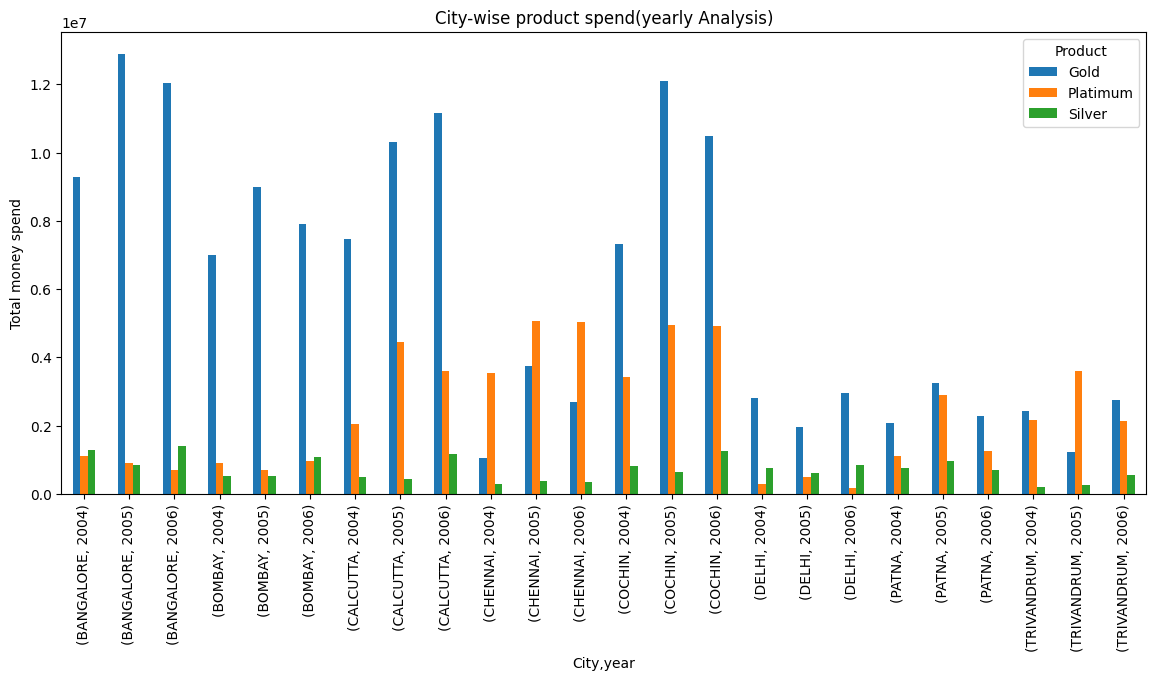

In [77]:
pivot_table = pivot_table.round(2)
pivot_table.plot.bar(figsize=(14,6))
plt.ylabel("Total money spend")
plt.title("City-wise product spend(yearly Analysis)")
plt.show()

1e7 likha hai (10⁷)

Create graphs for

1. Monthly comparison of total spends, city wise

In [78]:
pivot_table=spend_customer.pivot_table(index='month',columns='City',values='Amount',aggfunc=sum)
pivot_table

C:\Users\singh\AppData\Local\Temp\ipykernel_11656\2354633672.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pivot_table=spend_customer.pivot_table(index='month',columns='City',values='Amount',aggfunc=sum)


City,BANGALORE,BOMBAY,CALCUTTA,CHENNAI,COCHIN,DELHI,PATNA,TRIVANDRUM
month,,,,,,,,
1,9041796.84,5948993.33,9064864.90,4466961.36,11714373.54,2714261.45,4916205.55,3704336.99
2,6734494.76,4276988.30,8150545.61,4385815.95,5747886.38,1494064.06,2353333.55,2857123.89
3,5362903.07,5227850.50,4939040.04,3183643.71,5645146.53,2267149.02,1437166.61,2392316.51
4,4207980.48,1873785.01,3457507.95,2518656.99,3882744.94,777240.75,2338179.53,1199293.45
5,6383115.13,3891945.60,5578246.87,2856199.62,6581085.69,1600322.07,2136586.80,2813534.48
6,1330685.90,1172594.97,2293045.81,1244242.16,2495745.07,511276.09,746186.13,400336.83
7,2228217.69,177726.32,2234573.27,693825.77,1290897.30,50001.50,50000.00,260484.50
8,695061.95,1066744.75,1548354.02,305875.97,2317306.61,155402.16,419383.64,453773.94
9,703018.28,1278402.79,1511713.57,745759.40,1382242.90,50001.00,70329.95,186063.70


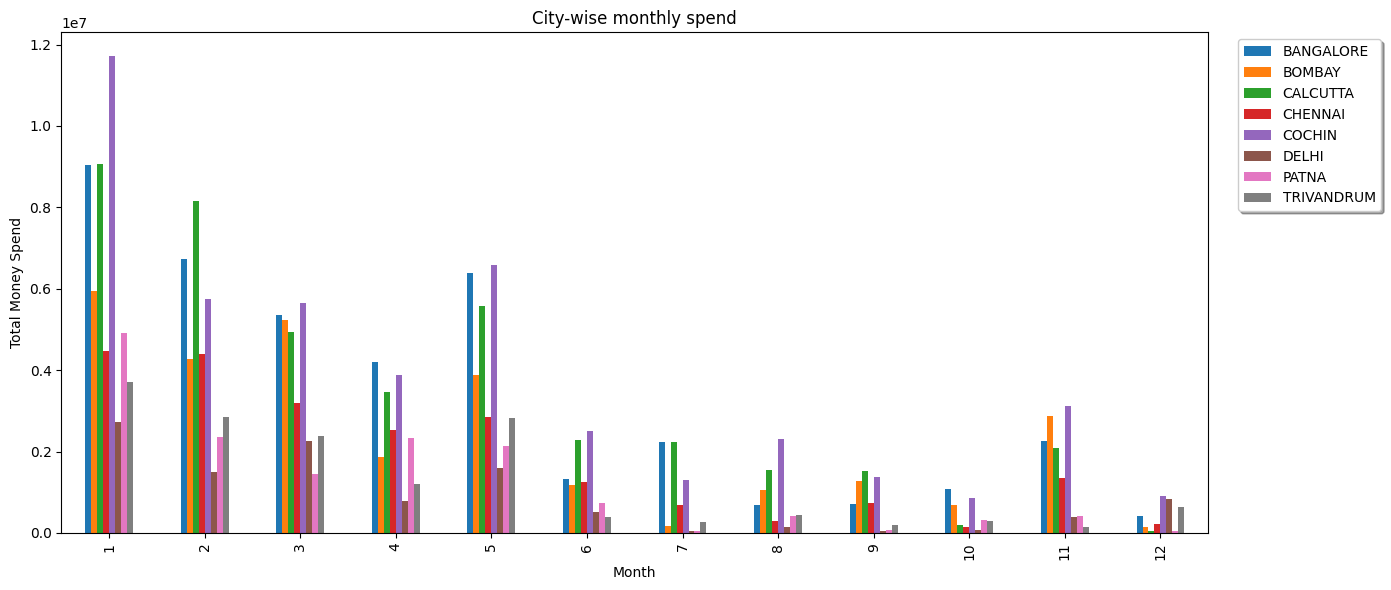

In [79]:
ax = pivot_table.plot.bar(figsize=(14,6))
ax.set_ylabel("Total Money Spend")
ax.set_title("City-wise monthly spend")
ax.set_xlabel("Month")
# Legend placed outside (right side, top aligned)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), shadow=True, ncol=1)
# Adjust layout so legend doesn't get cut
plt.tight_layout()
plt.show()

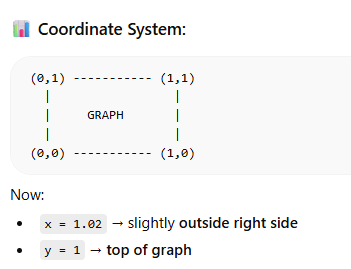

 Comparison of yearly spend on air tickets 

In [80]:
filtered_data=spend_customer.loc[(spend_customer['Type']=='AIR TICKET')]
filtered_data


,No,Customer,Age,City,Product,Limit,Company,Segment,Sl No:,Month,Type,Amount,month,year
9,1,A1,76.00,BANGALORE,Gold,500000.0,C1,Self Employed,131,2006-04-19,AIR TICKET,346925.68,4,2006
63,5,A5,56.00,BANGALORE,Platimum,10002.0,C5,Normal Salary,275,2006-03-03,AIR TICKET,5001.00,3,2006
80,6,A6,70.00,DELHI,Silver,100000.0,C6,Self Employed,276,2006-04-03,AIR TICKET,50000.00,4,2006
97,7,A7,26.00,COCHIN,Silver,100001.0,C7,Salaried_MNC,277,2006-05-03,AIR TICKET,50000.50,5,2006
115,8,A8,67.00,PATNA,Silver,100002.0,C8,Salaried_Pvt,278,2006-06-03,AIR TICKET,50001.00,6,2006
133,9,A9,79.00,CHENNAI,Silver,100003.0,C9,Govt,279,2006-07-03,AIR TICKET,50001.50,7,2006
135,9,A9,79.00,CHENNAI,Silver,100003.0,C9,Govt,315,2004-01-15,AIR TICKET,50001.50,1,2004
151,10,A10,54.00,CALCUTTA,Gold,500000.0,C10,Normal Salary,280,2006-08-03,AIR TICKET,454827.23,8,2006
156,11,A11,35.00,COCHIN,Gold,500000.0,C11,Normal Salary,11,2005-02-23,AIR TICKET,307622.01,2,2005
160,11,A11,35.00,COCHIN,Gold,500000.0,C11,Normal Salary,155,2005-06-01,AIR TICKET,272982.02,6,2005


In [81]:
pivot_table=filtered_data.pivot_table(index="year",values='Amount',aggfunc=sum)
print(pivot_table)

           Amount
year             
2004   4357225.35
2005  10550152.21
2006   5248469.56


C:\Users\singh\AppData\Local\Temp\ipykernel_11656\1187003665.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pivot_table=filtered_data.pivot_table(index="year",values='Amount',aggfunc=sum)


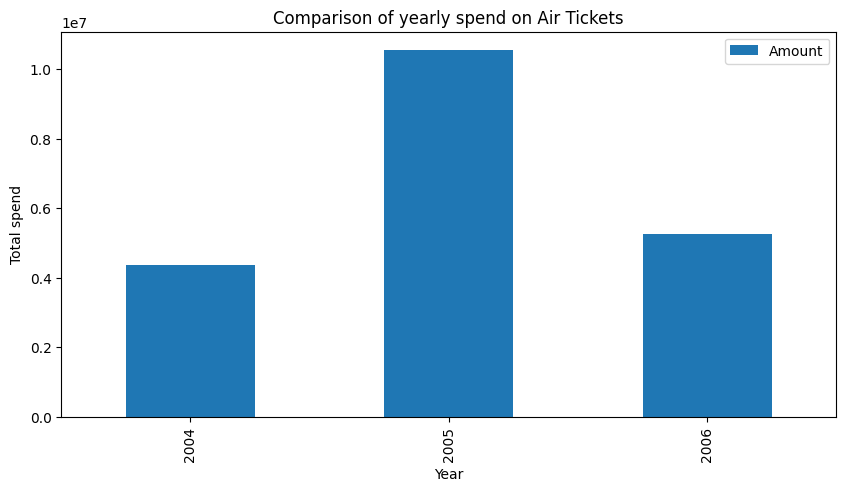

In [82]:
ax=pivot_table.plot.bar(figsize=(10,5))
ax.set_xlabel("Year")
ax.set_ylabel("Total spend")
ax.set_title("Comparison of yearly spend on Air Tickets")
plt.show()

Comparison of monthly spend for each product (look for any seasonality that exists in 
terms of spend) 

In [83]:
pivot_table=spend_customer.pivot_table(index='month',columns='Product',values="Amount",aggfunc=sum)
pivot_table

C:\Users\singh\AppData\Local\Temp\ipykernel_11656\2836310117.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pivot_table=spend_customer.pivot_table(index='month',columns='Product',values="Amount",aggfunc=sum)


Product,Gold,Platimum,Silver
month,,,
1,32413831.83,14951578.51,4206383.62
2,24779179.55,9134054.58,2087018.37
3,19256972.48,7288837.68,3909405.83
4,13170572.59,5182493.86,1902322.65
5,21548169.76,8151926.49,2140940.01
6,6538862.64,2965712.71,689537.61
7,5167416.37,1288156.26,530153.72
8,4954030.42,1714762.80,293109.82
9,3816887.62,1667840.84,442803.13


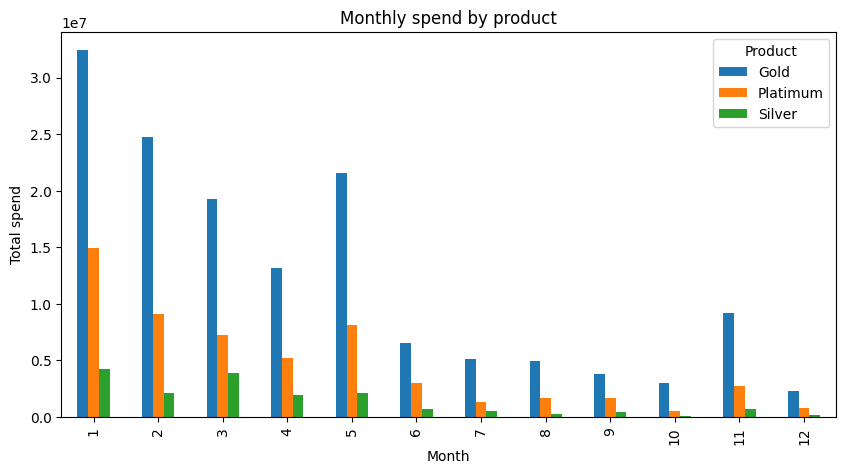

In [84]:
ax=pivot_table.plot.bar(figsize=(10,5))
ax.set_xlabel("Month")
ax.set_ylabel("Total spend")
ax.set_title("Monthly spend by product")
plt.show()

Overall Product spend comparison:

Gold: consistently has the highest monthly spend among these three products

Platinum: has the second highest spend

Silver: has the lowest spend throughout the year

Seasonality and Trends:

Peak spending: The highest spending for all the products occurs in the initial months, with a significant peak for Gold in month 1 (~ 3.2*10^7)

Trough spending: Spending is lowest around months 9 and 10

End-of-year increase: There is a noticeable increase in spending for Gold and Platinum in months 11 and 12, particularly for gold in month 11.

seasonality conclusion: The pattern of high spending at the biginning of the year, a mid-year dip, and an increase towards the end of the year 
suggest a seasonal pattern in customer spending habits for these products.





Write user defined PYTHON function to perform the following analysis: 

You need to find top 10 customers for each city in terms of their repayment amount by 
different products and by different time periods i.e. year or month. The user should be able 
to specify the product (Gold/Silver/Platinum) and time period (yearly or monthly) and the 
function should automatically take these inputs while identifying the top 10 customers.

In [85]:
repay_customer['Month']=pd.to_datetime(repay_customer['Month'])
repay_customer['year']=repay_customer['Month'].dt.year


In [86]:
def top_10_customers(data):
    product=input("Enter the product (Gold/Silver/Platinum):")
    time_period=input("Enter the time period (monthly/yearly):")
    
    # filter product
    data=data.loc[data['Product']==product]
    
    if time_period.lower()=="monthly":
        
        grouped=data.groupby(['Customer','City','month','Product'])['Amount'].sum().reset_index()
        result= grouped.sort_values(by=['City','month','Amount'],ascending=[True,True,False]).groupby(['City','month']).head(10).reset_index(drop=True)
        pivot=result.pivot_table(index=['City','Customer','Product'],columns='month',values='Amount').reset_index()
        pivot.columns.name=None
        return pivot
        
    elif time_period.lower()=="yearly":
        
        grouped=data.groupby(['Customer','City','year','Product'])['Amount'].sum().reset_index()
        result= grouped.sort_values(by=['City','year','Amount'],ascending=[True,True,False]).groupby(['City','year']).head(10).reset_index(drop=True)
        pivot=result.pivot_table(index=['City','Customer','Product'],columns='year',values='Amount').reset_index()
        pivot.columns.name=None
        return pivot
    
    else:
        raise ValueError("Invalid Time Period. Enter 'monthly' or 'yearly'")

In [87]:
import pandas as pd
pd.set_option('display.max_rows',None)
top_10_customers(repay_customer)

,City,Customer,Product,1,2,3,4,5,6,7,8,9,10,11,12
0,BANGALORE,A1,Gold,2407806.29,781873.80,NaN,508949.16,NaN,NaN,297176.74,NaN,186427.50,NaN,571458.18,NaN
1,BANGALORE,A13,Gold,2014186.98,2049808.15,1183569.05,494392.40,632600.75,837101.91,424603.55,873304.51,439840.91,NaN,622592.45,NaN
2,BANGALORE,A14,Gold,993114.87,1482923.34,1682886.51,812582.20,1418286.63,41128.98,41962.19,198623.13,462300.80,NaN,420638.02,388821.96
3,BANGALORE,A30,Gold,608066.49,1321469.80,599331.38,425694.16,3086549.14,72609.24,NaN,NaN,19761.75,NaN,NaN,NaN
4,BANGALORE,A43,Gold,1978038.15,763846.93,1378774.72,612541.80,2058983.99,23525.91,803935.53,NaN,NaN,415860.27,454364.16,NaN
5,BANGALORE,A63,Gold,372179.26,NaN,NaN,NaN,416676.34,NaN,NaN,NaN,NaN,NaN,211117.12,NaN
6,BANGALORE,A81,Gold,NaN,NaN,207780.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,BANGALORE,A88,Gold,NaN,NaN,146821.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,BANGALORE,A92,Gold,NaN,NaN,NaN,459105.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,BOMBAY,A12,Gold,1220387.18,1978117.59,1001134.17,601326.07,1048233.62,526225.82,1201928.94,120471.17,289407.01,347528.59,NaN,NaN


In [ ]:
00